RQ 4: Are there any noticeable patterns in game outcomes depending on the day of the week (e.g., Sunday vs. Monday Night Football)?

I will be using the games dataset as it clearly lists the DOW for each entry and there are 5,000+ entries

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

games = pd.read_csv('games.csv')


In [34]:
games.head(3)

,year,week,home_team,away_team,winner,tie,day,date,time,pts_win,pts_loss,yds_win,turnovers_win,yds_loss,turnovers_loss,home_team_name,home_team_city,away_team_name,away_team_city
0,2000,1,Minnesota Vikings,Chicago Bears,Minnesota Vikings,NaN,Sun,September 3,1:00PM,30,27,374,1,425,1,Vikings,Minnesota,Bears,Chicago
1,2000,1,Kansas City Chiefs,Indianapolis Colts,Indianapolis Colts,NaN,Sun,September 3,1:00PM,27,14,386,2,280,1,Chiefs,Kansas City,Colts,Indianapolis
2,2000,1,Washington Redskins,Carolina Panthers,Washington Redskins,NaN,Sun,September 3,1:01PM,20,17,396,0,236,1,Redskins,Washington,Panthers,Carolina


GROUP BY "day" column and compute the average of stats we care about (points scored, yards gained, turnovers)

In [38]:
day_summary = games.groupby('day').agg({
    'pts_win': 'mean',
    'pts_loss': 'mean',
    'turnovers_win': 'mean',
    'yds_win': 'mean',
    'yds_loss': 'mean',
    'turnovers_loss': 'mean',
    
}).reset_index()

day_summary


,day,pts_win,pts_loss,turnovers_win,yds_win,yds_loss,turnovers_loss
0,Fri,35.333333,22.666667,0.666667,449.000000,324.000000,1.333333
1,Mon,28.935103,16.297935,1.026549,364.333333,310.696165,2.235988
2,Sat,28.056180,16.438202,1.056180,363.825843,309.359551,2.140449
3,Sun,27.658675,16.063862,1.097210,361.298605,308.898649,2.168919
4,Thu,28.289720,15.915888,0.827103,361.322430,310.065421,2.065421
5,Tue,24.000000,14.000000,1.000000,337.000000,331.000000,3.000000
6,Wed,24.000000,17.000000,1.000000,433.000000,269.000000,1.000000


Order the weekdays for more readable visualizations

In [39]:
weekly_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

Quick Summary Visualizations: 

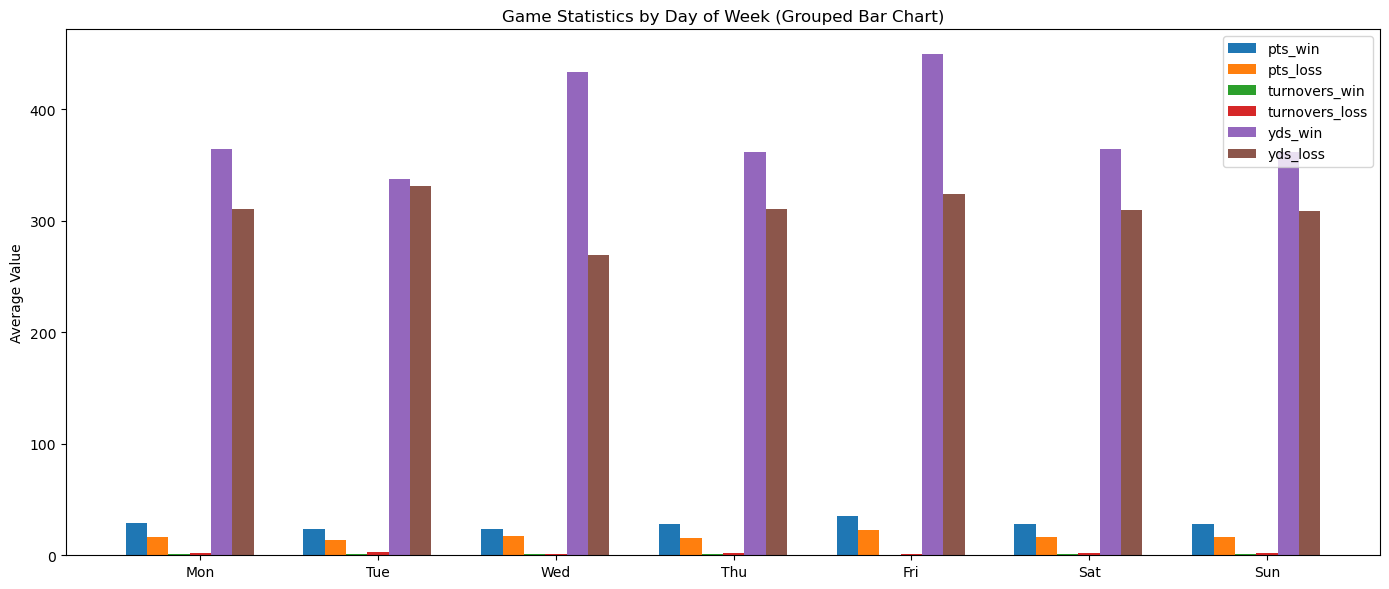

In [46]:
import numpy as np

metrics = ["pts_win", "pts_loss", "turnovers_win", "turnovers_loss", "yds_win", "yds_loss"]

df = day_summary.set_index("day").reindex(weekly_order)

x = np.arange(len(df.index))
width = 0.12  

plt.figure(figsize=(14, 6))

for i, m in enumerate(metrics):
    plt.bar(x + i * width, df[m], width, label=m)

plt.xticks(x + width * (len(metrics) / 2), df.index)

plt.ylabel("Average Value")
plt.title("Game Statistics by Day of Week (Grouped Bar Chart)")
plt.legend()
plt.tight_layout()
plt.show()



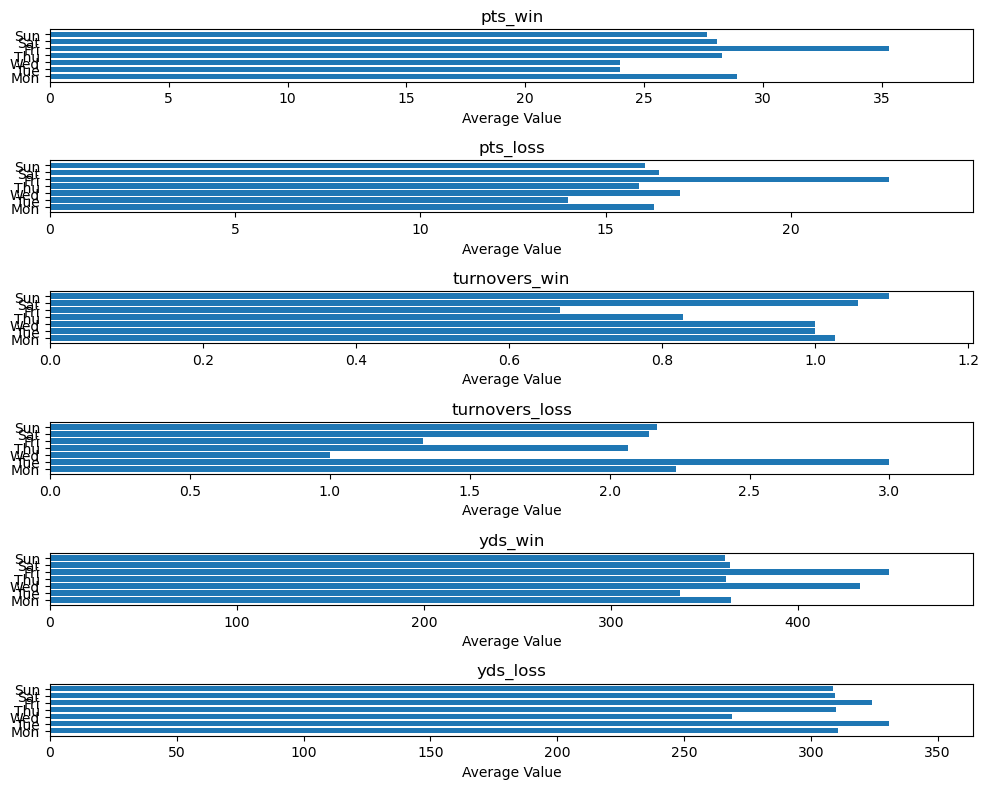

In [49]:
df = day_summary.set_index("day").reindex(weekly_order)

plt.figure(figsize=(10, 8))

for i, m in enumerate(metrics):
    plt.subplot(len(metrics), 1, i + 1)
    plt.barh(df.index, df[m])
    plt.title(m)
    plt.xlabel("Average Value")
    plt.xlim(0, df[m].max() * 1.1) 

plt.tight_layout()
plt.show()

Visualize average total points scored (for both winning and losing teams) per day-of-week. This will show if certain days of the week are generally more high-scoring (for winners, for losers, for both, etc)

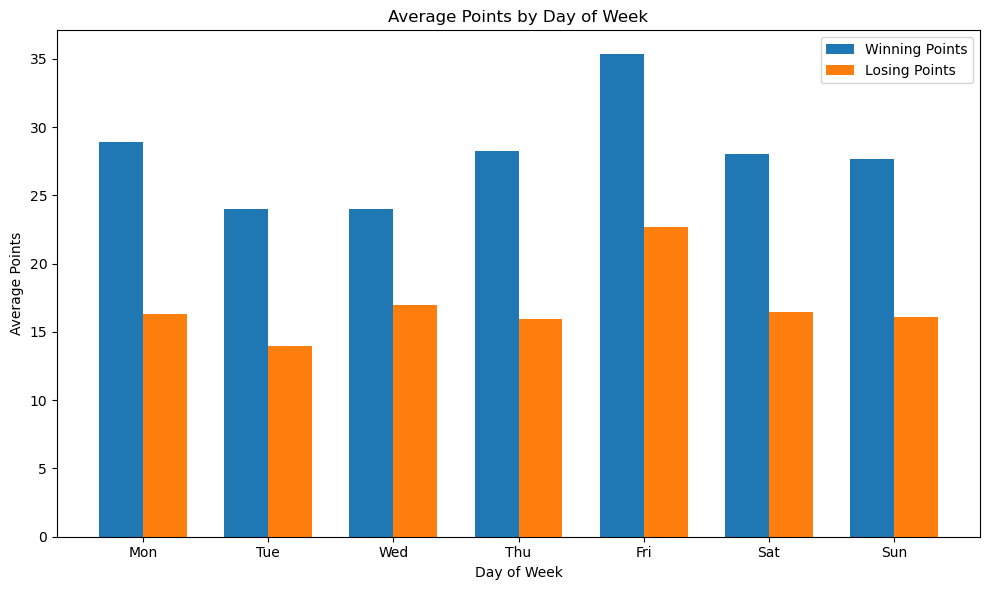

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
day_summary = games.groupby('day')[['pts_win', 'pts_loss']].mean()

day_summary = day_summary.reindex([d for d in weekly_order if d in day_summary.index])

plt.figure(figsize=(10, 6))

x = np.arange(len(day_summary))
width = 0.35

plt.bar(x - width/2, day_summary['pts_win'], width, label='Winning Points')
plt.bar(x + width/2, day_summary['pts_loss'], width, label='Losing Points')

plt.xticks(x, day_summary.index)
plt.xlabel("Day of Week")
plt.ylabel("Average Points")
plt.title("Average Points by Day of Week")
plt.legend()
plt.tight_layout()
plt.show()


Fridays tend to be more high-scoring for both the winning and losing teams than any other DOW! Tuesday and Wednesday have, on average, the least points scored by both teams per game.

Visualize average closeness of the games across DOW

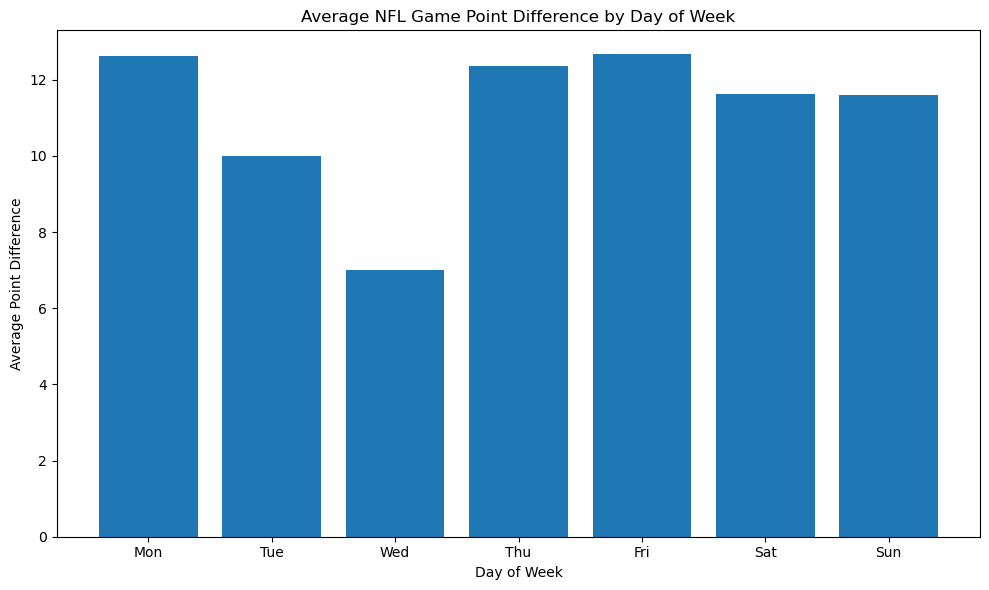

In [51]:
games['point_diff'] = games['pts_win'] - games['pts_loss']

day_diff = games.groupby('day')['point_diff'].mean()

day_diff = day_diff.reindex([d for d in weekly_order if d in day_diff.index])

plt.figure(figsize=(10, 6))
plt.bar(day_diff.index, day_diff.values)

plt.xlabel("Day of Week")
plt.ylabel("Average Point Difference")
plt.title("Average NFL Game Point Difference by Day of Week")
plt.tight_layout()
plt.show()


Tuesday and Wednesday games are closer-scoring than other days of the week. Monday and Friday games are the least close in terms of score.

Compare average offensive yards gained (for winning and losing team) per game across day-of week:

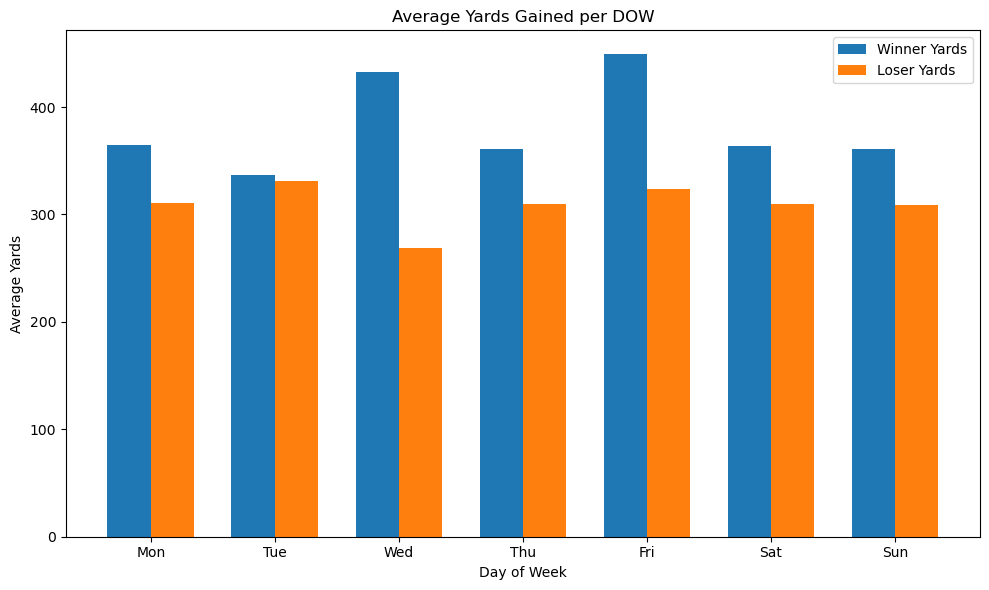

In [53]:

yard_summary = games.groupby('day')[['yds_win', 'yds_loss']].mean()

yard_summary = yard_summary.reindex([d for d in weekly_order if d in yard_summary.index])

plt.figure(figsize=(10, 6))

x = range(len(yard_summary))
width = 0.35

plt.bar([i - width/2 for i in x], yard_summary['yds_win'], width, label="Winner Yards")
plt.bar([i + width/2 for i in x], yard_summary['yds_loss'], width, label="Loser Yards")

plt.xticks(x, yard_summary.index)
plt.xlabel("Day of Week")
plt.ylabel("Average Yards")
plt.title("Average Yards Gained per DOW")
plt.legend()
plt.tight_layout()
plt.show()

No crazy noticeable patterns, but Wednesday and Friday have significantly more offensive intensity for their winning teams than other days

Visualize average turnovers (for both winning and losing team) across day of week

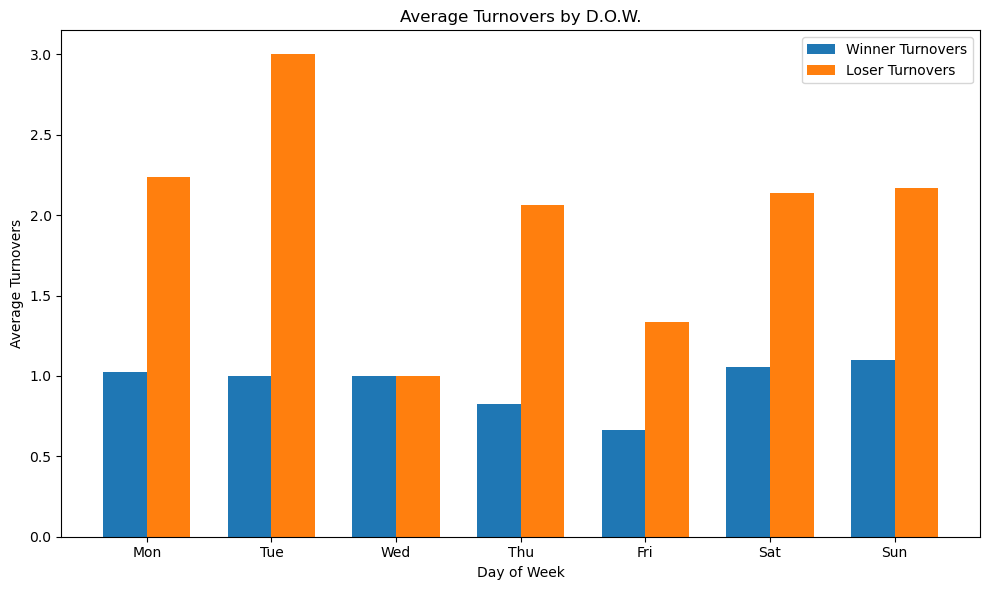

In [22]:
turnover_summary = games.groupby('day')[['turnovers_win', 'turnovers_loss']].mean()

turnover_summary = turnover_summary.reindex([d for d in weekly_order if d in turnover_summary.index])

plt.figure(figsize=(10, 6))

x = range(len(turnover_summary))
width = 0.35

plt.bar([i - width/2 for i in x], turnover_summary['turnovers_win'], width, label="Winner Turnovers")
plt.bar([i + width/2 for i in x], turnover_summary['turnovers_loss'], width, label="Loser Turnovers")

plt.xticks(x, turnover_summary.index)
plt.xlabel("Day of Week")
plt.ylabel("Average Turnovers")
plt.title("Average Turnovers by D.O.W.")
plt.legend()
plt.tight_layout()
plt.show()


Losers have more turnovers on Tuesday. Winners play the sharpest (least turnovers) on Fridays!

Based on this analysis, it seems that NFL teams (especially the winning team of the game) play the strongest on Fridays. Average points scored (for both winners and losers) are highest on Fridays as compared to every other DOW. Friday is the day with the highest game point difference as well, meaning that winning teams on Fridays beat their opponents by higher margins on average. The winning team, on average, gains the most offensive yards on Fridays compared to every other DOW. And sloppiness (in terms of turnovers) are lowest on Fridays for BOTH the winning and losing teams!